In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.utils import build_covariance_matrix
from neural_network.trainer import SobolevTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import Put

from binomial_tree.binomial_tree import binomial_tree


In [2]:
S0 = 1.0
r = 0.1
sigma = 0.4
K = 2.0
T = 1.0
S_min = 0.0
S_max = 3 * K

market_params = MarketParams(n_assets=1, S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [3]:
input_size = 2
hidden_sizes = [32, 32, 32]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [7]:
put_payoff = Put()
trainer = SobolevTrainer(model_config, market_params, put_payoff, seed=42)
trainer.train(batch_size=1000, epochs=10000, tol=1e-5)

Iteration 0, Loss: 6.328371524810791
Iteration 100, Loss: 0.3815520107746124
Iteration 200, Loss: 0.22708870470523834
Iteration 300, Loss: 0.22738082706928253
Iteration 400, Loss: 0.22732646763324738
Iteration 500, Loss: 0.23294515907764435
Iteration 600, Loss: 0.2299560308456421
Iteration 700, Loss: 0.23304115235805511
Iteration 800, Loss: 0.2337012141942978
Iteration 900, Loss: 0.25713860988616943
Iteration 1000, Loss: 0.23520176112651825
Iteration 1100, Loss: 0.2315376102924347
Iteration 1200, Loss: 0.24452173709869385
Iteration 1300, Loss: 0.2624964118003845
Iteration 1400, Loss: 0.229230135679245
Converged at epoch 1443


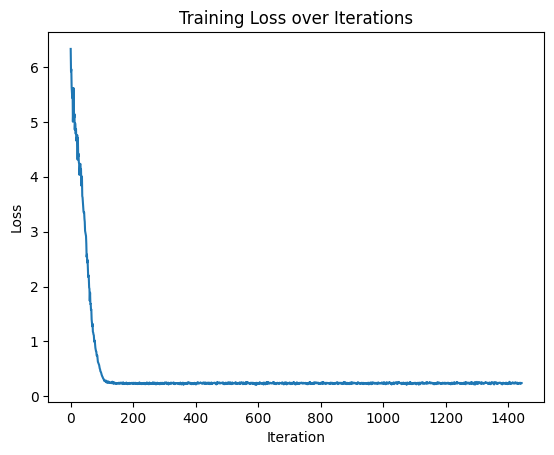

In [8]:
trainer.plot_losses()

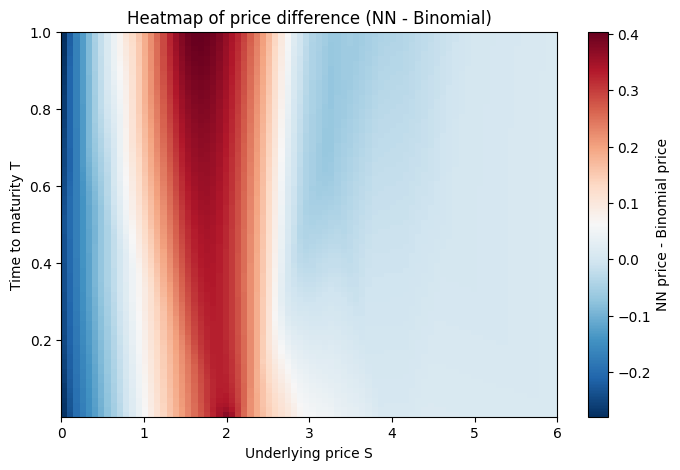

In [11]:
# grid resolution
num_S = 80
num_T = 80

Ss = np.linspace(S_min, S_max, num_S)
Ts = np.linspace(1e-6, T, num_T)  # avoid exactly zero maturity

nn_prices = np.zeros((num_T, num_S))
bt_prices = np.zeros((num_T, num_S))

for i, t_val in enumerate(Ts):
    for j, s_val in enumerate(Ss):
        nn_prices[i, j] = trainer.predict(t_val, s_val).item()
        bt_price, _, _ = binomial_tree(S=s_val, K=K, T=t_val, r=r, sigma=sigma, n=200)
        bt_prices[i, j] = float(bt_price)

diff = nn_prices - bt_prices

plt.figure(figsize=(8, 5))
im = plt.imshow(diff, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='NN price - Binomial price')
plt.xlabel('Underlying price S')
plt.ylabel('Time to maturity T')
plt.title('Heatmap of price difference (NN - Binomial)')
plt.show()

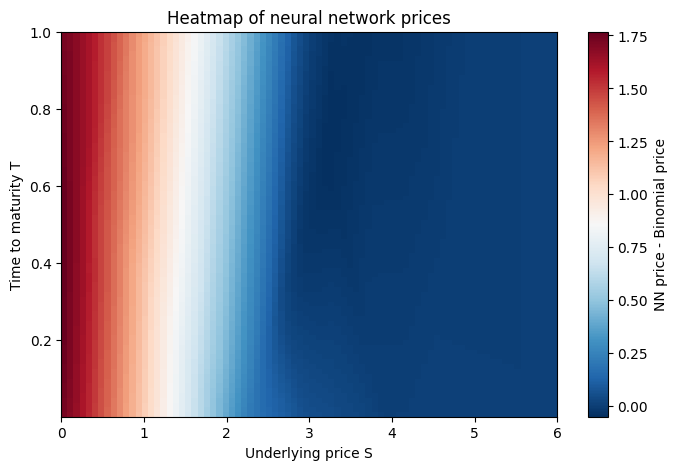

In [12]:
plt.figure(figsize=(8, 5))
im = plt.imshow(nn_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='NN price - Binomial price')
plt.xlabel('Underlying price S')
plt.ylabel('Time to maturity T')
plt.title('Heatmap of neural network prices')
plt.show()

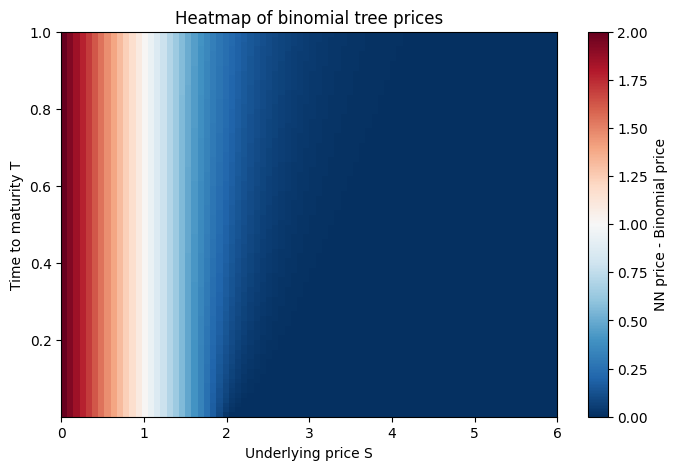

In [13]:
plt.figure(figsize=(8, 5))
im = plt.imshow(bt_prices, extent=[Ss[0], Ss[-1], Ts[0], Ts[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(im, label='NN price - Binomial price')
plt.xlabel('Underlying price S')
plt.ylabel('Time to maturity T')
plt.title('Heatmap of binomial tree prices')
plt.show()